In [ ]:
!pip install tensorflow tensorflow-datasets pandas scikit-learn importlib_resources xgboost matplotlib seaborn

In [1]:
import tensorflow_datasets as tfds
import tensorflow as tf

import pandas as pd
import os
from pathlib import Path

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
BASE_DIR = Path.cwd().parent
print(f"Base directory: {BASE_DIR}")

DATA_DIR = Path(BASE_DIR / "src" / "data")
print(f"Data directory: {DATA_DIR}")

Base directory: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring
Data directory: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\src\data


In [3]:
# Load dataset
hillstrom_filepath = DATA_DIR / "hillstrom.csv"

if not hillstrom_filepath.exists():
    
    hillstrom_ds= tfds.load(
        "hillstrom",
        split=["train"],
        as_supervised=False
    )
    rows = []

    for sample in tfds.as_numpy(hillstrom_ds[0]):

        row = {
            "channel": sample["channel"].decode("utf-8"),
            "conversion": int(sample["conversion"]),
            "history": float(sample["history"]),
            "history_segment": sample["history_segment"].decode("utf-8"),
            "mens": int(sample["mens"]),
            "newbie": int(sample["newbie"]),
            "recency": int(sample["recency"]),
            "segment": sample["segment"].decode("utf-8"),
            "spend": float(sample["spend"]),
            "visit": int(sample["visit"]),
            "womens": int(sample["womens"]),
            "zip_code": sample["zip_code"].decode("utf-8"),
        }

        rows.append(row)
    hillstrom_df = pd.DataFrame(rows)

    hillstrom_df.to_csv(hillstrom_filepath, index=False)

    print(f"Saved to: {hillstrom_filepath}")

elif hillstrom_filepath.exists():
    print(f"File already exists at: {hillstrom_filepath}")
    hillstrom_df = pd.read_csv(hillstrom_filepath)



print(hillstrom_df.shape)
hillstrom_df.head()

File already exists at: c:\Users\kuchbhe\Desktop\Projects_doc\lead_scoring\src\data\hillstrom.csv
(64000, 12)


,channel,conversion,history,history_segment,mens,newbie,recency,segment,spend,visit,womens,zip_code
0,Multichannel,0,328.160004,3) $200 - $350,0,0,3,Mens E-Mail,0.0,0,1,Urban
1,Web,0,70.860001,1) $0 - $100,1,0,9,No E-Mail,0.0,0,0,Rural
2,Phone,0,94.250000,1) $0 - $100,1,1,12,No E-Mail,0.0,0,0,Surburban
3,Web,0,304.350006,3) $200 - $350,0,0,5,Mens E-Mail,0.0,0,1,Urban
4,Web,0,222.860001,3) $200 - $350,1,0,4,Mens E-Mail,0.0,1,0,Urban


In [4]:
hillstrom_df.describe()

,conversion,history,mens,newbie,recency,spend,visit,womens
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,0.009031,242.085656,0.551031,0.502250,5.763734,1.050908,0.146781,0.549719
std,0.094604,256.158608,0.497393,0.499999,3.507592,15.036448,0.353890,0.497526
min,0.000000,29.990000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,64.660004,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,0.000000,158.110001,1.000000,1.000000,6.000000,0.000000,0.000000,1.000000
75%,0.000000,325.657494,1.000000,1.000000,9.000000,0.000000,0.000000,1.000000
max,1.000000,3345.929932,1.000000,1.000000,12.000000,499.000000,1.000000,1.000000


In [5]:
missing_summary = pd.DataFrame({
    "missing_count": hillstrom_df.isnull().sum(),
    "missing_pct": hillstrom_df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    by="missing_pct",
    ascending=False
)

print(missing_summary)

                 missing_count  missing_pct
channel                      0          0.0
conversion                   0          0.0
history                      0          0.0
history_segment              0          0.0
mens                         0          0.0
newbie                       0          0.0
recency                      0          0.0
segment                      0          0.0
spend                        0          0.0
visit                        0          0.0
womens                       0          0.0
zip_code                     0          0.0


In [6]:
hillstrom_df['conversion'].value_counts(normalize=True)

conversion
0    0.990969
1    0.009031
Name: proportion, dtype: float64

In [7]:
hillstrom_df["spend_level"] = (
    hillstrom_df["history_segment"]
    .str.extract(r"(\d+)")
    .astype(int)
)

hillstrom_df.drop(
    columns=["history_segment"],
    inplace=True
)


hillstrom_df.drop(
    columns=[
        "spend",
        "visit",
        "segment"
    ],
    inplace=True
)

TARGET_COL = "conversion"

NUM_COLS = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie",
    "spend_level"
]

CAT_COLS = [
    "channel",
    "zip_code"
]


train_df, test_df = train_test_split(
    hillstrom_df,
    test_size=0.2,
    random_state=42,
    stratify=hillstrom_df[TARGET_COL]
)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_COLS),
        ("cat", categorical_transformer, CAT_COLS)
    ]
)

In [ ]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l1",
                solver="saga",
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

lr_pipeline.fit(X_train, y_train)

print(
    classification_report(
        y_test, lr_pipeline.predict(X_test)
    )
)

c:\Users\kuchbhe\Desktop\Projects_doc\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kuchbhe\Desktop\Projects_doc\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.99      0.59      0.74     12684
           1       0.01      0.55      0.02       116

    accuracy                           0.58     12800
   macro avg       0.50      0.57      0.38     12800
weighted avg       0.98      0.59      0.73     12800



In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

print(
    classification_report(
        y_test, rf_pipeline.predict(X_test)
    )   
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     12684
           1       0.02      0.07      0.03       116

    accuracy                           0.96     12800
   macro avg       0.50      0.52      0.50     12800
weighted avg       0.98      0.96      0.97     12800



In [12]:
from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Scale pos weight: {scale_pos_weight:.2f}")

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                scale_pos_weight=scale_pos_weight
            )
        )
    ]
)

xgb_pipeline.fit(X_train, y_train)

print(
    classification_report(
        y_test, xgb_pipeline.predict(X_test)
    )   
)

Scale pos weight: 109.82
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     12684
           1       0.01      0.22      0.03       116

    accuracy                           0.86     12800
   macro avg       0.50      0.54      0.47     12800
weighted avg       0.98      0.86      0.91     12800



In [17]:
lr_scores = lr_pipeline.predict_proba(X_test)[:, 1]

rf_scores = rf_pipeline.predict_proba(X_test)[:, 1]

xgb_scores = xgb_pipeline.predict_proba(X_test)[:, 1]


results_df = X_test.copy()

results_df["conversion"] = y_test.values

results_df["xgb_score"] = xgb_scores

results_df["rf_score"] = rf_scores

results_df["lr_score"] = lr_scores

results_df = results_df.sort_values(
    by="lr_score",
    ascending=False
)

results_df.head()

,channel,history,mens,newbie,recency,womens,zip_code,spend_level,conversion,xgb_score,rf_score,lr_score
8026,Web,3040.199951,0,1,1,1,Urban,7,0,0.858960,0.434741,0.783891
259,Multichannel,1716.010010,1,1,1,1,Rural,7,0,0.033413,0.098213,0.760724
60244,Phone,1864.310059,1,1,1,1,Rural,7,0,0.352293,0.228430,0.756875
47335,Phone,1853.660034,1,1,1,1,Rural,7,1,0.352293,0.228430,0.756521
47754,Multichannel,1395.719971,0,1,1,1,Rural,7,0,0.010724,0.063022,0.748545


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

K_VALUES = list(range(50, 101, 50)) + list(range(200, 1001, 100))

print(K_VALUES)

SCORE_COLS = {
    "Logistic Regression": "lr_score",
    "Random Forest": "rf_score",
    "XGBoost": "xgb_score",
}

def top_k_metrics(df, score_col, k_values, target_col="conversion"):
    total_conversions = df[target_col].sum()
    base_rate = df[target_col].mean()

    rows = []

    ranked = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    for k in k_values:
        top_k = ranked.head(k)
        conversions_at_k = top_k[target_col].sum()
        precision_at_k = conversions_at_k / k
        recall_at_k = conversions_at_k / total_conversions
        lift_at_k = precision_at_k / base_rate

        rows.append({
            "model": score_col,
            "K": k,
            "conversions_at_K": conversions_at_k,
            "precision_at_K": precision_at_k,
            "recall_at_K": recall_at_k,
            "capture_at_K": recall_at_k,
            "lift_at_K": lift_at_k,
        })

    return pd.DataFrame(rows)


all_metrics = []

for model_name, score_col in SCORE_COLS.items():
    model_metrics = top_k_metrics(
        results_df,
        score_col=score_col,
        k_values=K_VALUES,
        target_col="conversion"
    )
    model_metrics["model"] = model_name
    all_metrics.append(model_metrics)

metrics_df = pd.concat(all_metrics, ignore_index=True)

total_conversions = results_df["conversion"].sum()
base_rate = results_df["conversion"].mean()

random_rows = []

for k in K_VALUES:
    expected_conversions = k * base_rate

    random_rows.append({
        "model": "Random",
        "K": k,
        "conversions_at_K": expected_conversions,
        "precision_at_K": base_rate,
        "recall_at_K": expected_conversions / total_conversions,
        "capture_at_K": expected_conversions / total_conversions,
        "lift_at_K": 1.0,
    })

random_metrics_df = pd.DataFrame(random_rows)

metrics_df = pd.concat(
    [metrics_df, random_metrics_df],
    ignore_index=True
)

metrics_df[metrics_df['K'] == 50]

[50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


,model,K,conversions_at_K,precision_at_K,recall_at_K,capture_at_K,lift_at_K
0,Logistic Regression,50,3.000000,0.060000,0.025862,0.025862,6.620690
11,Random Forest,50,0.000000,0.000000,0.000000,0.000000,0.000000
22,XGBoost,50,1.000000,0.020000,0.008621,0.008621,2.206897
33,Random,50,0.453125,0.009062,0.003906,0.003906,1.000000


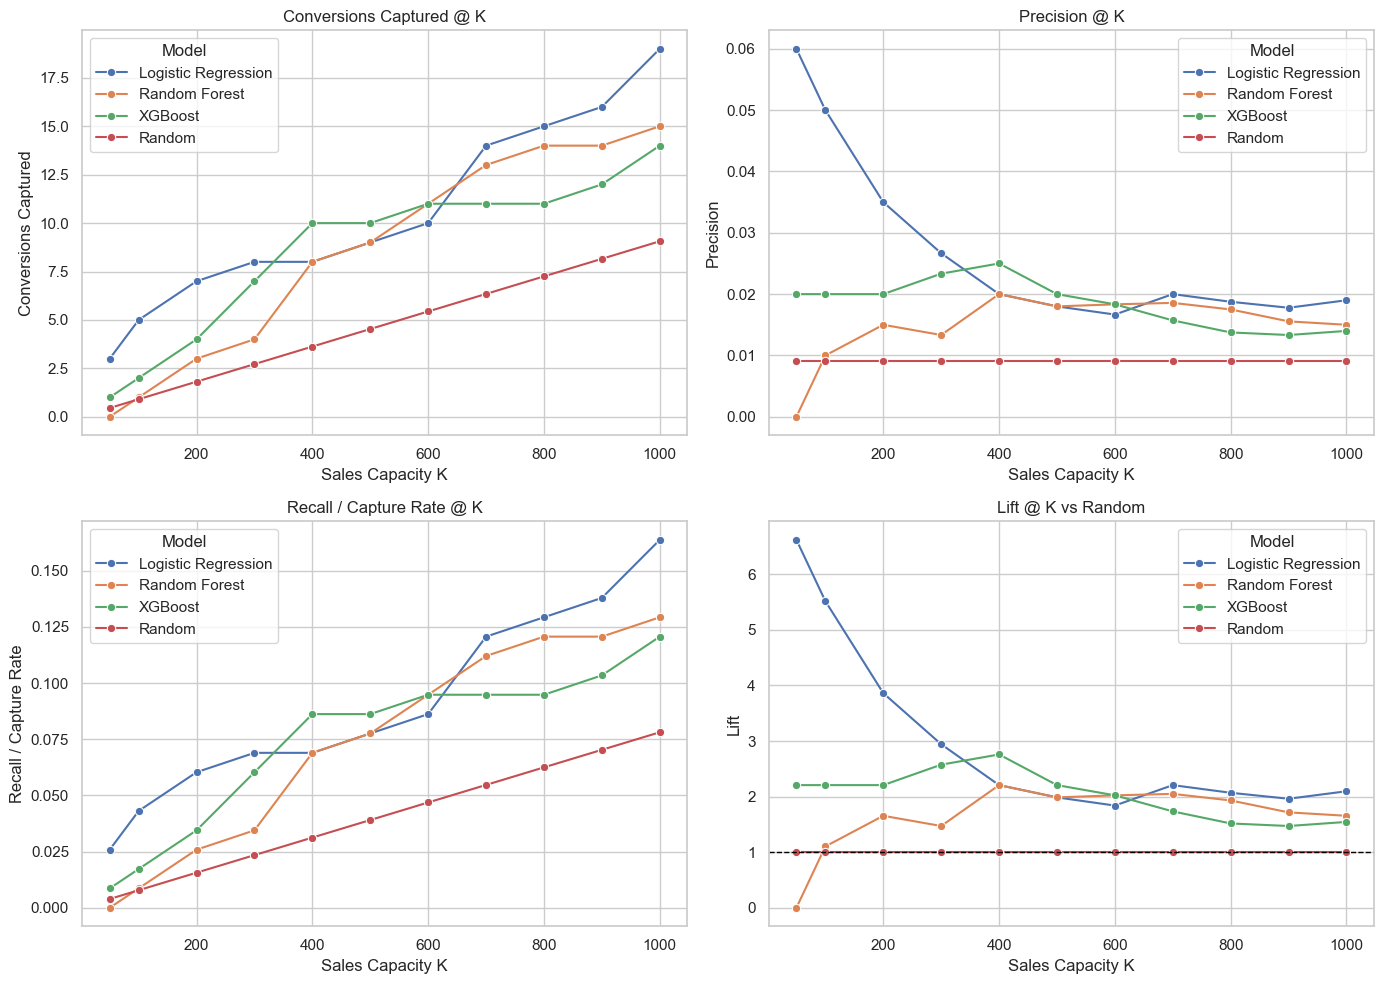

In [23]:
sns.set_theme(style="whitegrid")

plot_df = metrics_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.lineplot(
    data=plot_df,
    x="K",
    y="conversions_at_K",
    hue="model",
    marker="o",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Conversions Captured @ K")
axes[0, 0].set_ylabel("Conversions Captured")

sns.lineplot(
    data=plot_df,
    x="K",
    y="precision_at_K",
    hue="model",
    marker="o",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Precision @ K")
axes[0, 1].set_ylabel("Precision")

sns.lineplot(
    data=plot_df,
    x="K",
    y="recall_at_K",
    hue="model",
    marker="o",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Recall / Capture Rate @ K")
axes[1, 0].set_ylabel("Recall / Capture Rate")

sns.lineplot(
    data=plot_df,
    x="K",
    y="lift_at_K",
    hue="model",
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Lift @ K vs Random")
axes[1, 1].set_ylabel("Lift")

for ax in axes.flat:
    ax.set_xlabel("Sales Capacity K")
    ax.legend(title="Model")

plt.tight_layout()
plt.show()

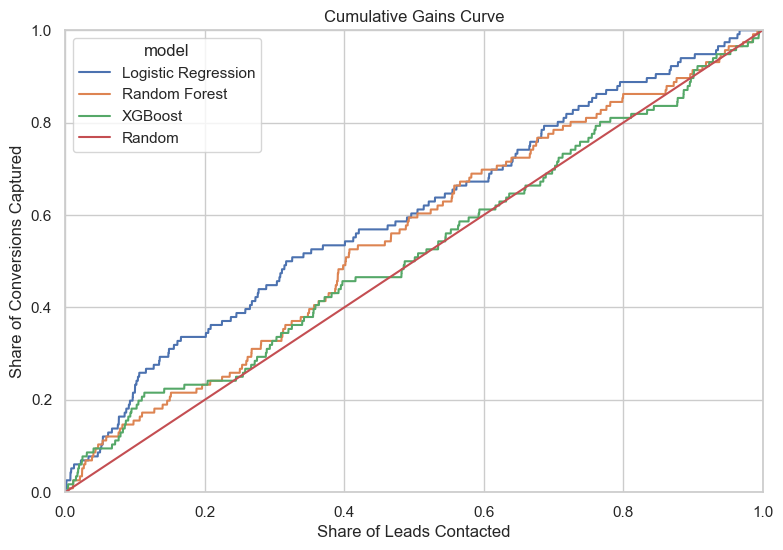

In [24]:
def cumulative_gains_df(df, score_cols, target_col="conversion"):
    rows = []
    total_conversions = df[target_col].sum()
    n = len(df)

    for model_name, score_col in score_cols.items():
        ranked = df.sort_values(score_col, ascending=False).reset_index(drop=True)
        ranked["cum_conversions"] = ranked[target_col].cumsum()
        ranked["sample_pct"] = (ranked.index + 1) / n
        ranked["capture_pct"] = ranked["cum_conversions"] / total_conversions

        rows.append(
            ranked[["sample_pct", "capture_pct"]]
            .assign(model=model_name)
        )

    random_curve = pd.DataFrame({
        "sample_pct": [0, 1],
        "capture_pct": [0, 1],
        "model": "Random"
    })

    return pd.concat(rows + [random_curve], ignore_index=True)


gains_df = cumulative_gains_df(
    results_df,
    SCORE_COLS,
    target_col="conversion"
)

plt.figure(figsize=(9, 6))

sns.lineplot(
    data=gains_df,
    x="sample_pct",
    y="capture_pct",
    hue="model"
)

plt.title("Cumulative Gains Curve")
plt.xlabel("Share of Leads Contacted")
plt.ylabel("Share of Conversions Captured")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score,
    roc_auc_score
)

sns.set_theme(style="whitegrid")

TARGET_COL = "conversion"

SCORE_COLS = {
    "Logistic Regression": "lr_score",
    "Random Forest": "rf_score",
    "XGBoost": "xgb_score",
}

In [26]:
summary_rows = []

for model_name, score_col in SCORE_COLS.items():
    y_true = results_df[TARGET_COL].values
    y_score = results_df[score_col].values

    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    summary_rows.append({
        "model": model_name,
        "PR_AUC_average_precision": pr_auc,
        "ROC_AUC": roc_auc,
    })

ranking_summary_df = pd.DataFrame(summary_rows)

ranking_summary_df.sort_values(
    "PR_AUC_average_precision",
    ascending=False
)

,model,PR_AUC_average_precision,ROC_AUC
0,Logistic Regression,0.018993,0.599930
2,XGBoost,0.011746,0.519556
1,Random Forest,0.011552,0.551870


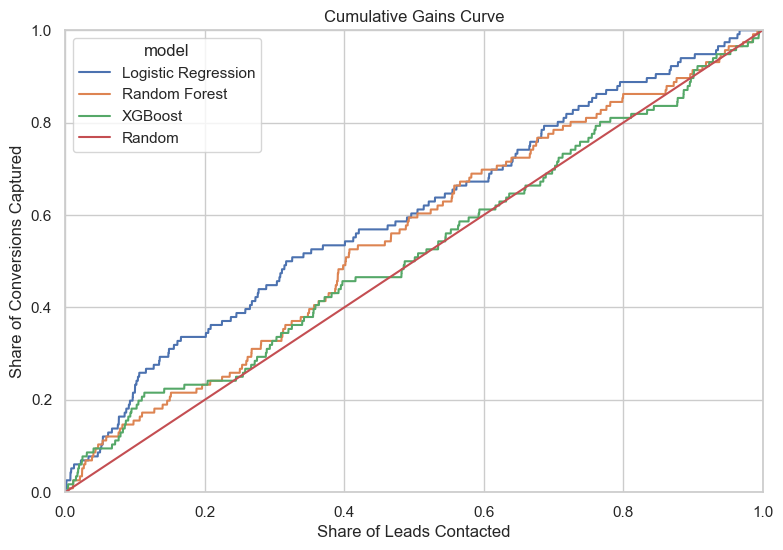

In [27]:
def make_cumulative_gains_df(df, score_cols, target_col="conversion"):
    rows = []
    total_conversions = df[target_col].sum()
    n = len(df)

    for model_name, score_col in score_cols.items():
        ranked = (
            df[[target_col, score_col]]
            .sort_values(score_col, ascending=False)
            .reset_index(drop=True)
        )

        ranked["rank"] = np.arange(1, n + 1)
        ranked["cum_conversions"] = ranked[target_col].cumsum()

        ranked["share_of_leads_contacted"] = ranked["rank"] / n
        ranked["share_of_conversions_captured"] = (
            ranked["cum_conversions"] / total_conversions
        )

        ranked["model"] = model_name

        rows.append(
            ranked[
                [
                    "model",
                    "share_of_leads_contacted",
                    "share_of_conversions_captured",
                ]
            ]
        )

    random_curve = pd.DataFrame({
        "model": "Random",
        "share_of_leads_contacted": [0, 1],
        "share_of_conversions_captured": [0, 1],
    })

    return pd.concat(rows + [random_curve], ignore_index=True)


gains_df = make_cumulative_gains_df(
    results_df,
    SCORE_COLS,
    target_col=TARGET_COL
)

plt.figure(figsize=(9, 6))

sns.lineplot(
    data=gains_df,
    x="share_of_leads_contacted",
    y="share_of_conversions_captured",
    hue="model"
)

plt.title("Cumulative Gains Curve")
plt.xlabel("Share of Leads Contacted")
plt.ylabel("Share of Conversions Captured")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

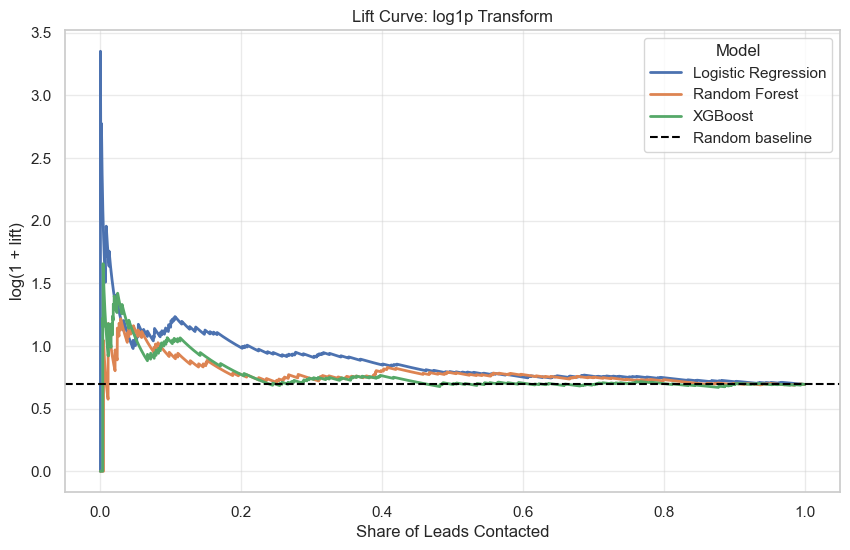

In [43]:
plot_lift_df = lift_df.copy()
plot_lift_df["log1p_lift_at_k"] = np.log1p(plot_lift_df["lift_at_k"])

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_lift_df,
    x="share_of_leads_contacted",
    y="log1p_lift_at_k",
    hue="model",
    linewidth=2
)

random_log1p = np.log1p(1.0)

plt.axhline(
    y=random_log1p,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline"
)

plt.title("Lift Curve: log1p Transform")
plt.xlabel("Share of Leads Contacted")
plt.ylabel("log(1 + lift)")
plt.legend(title="Model")
plt.grid(True, alpha=0.4)
plt.show()

In [47]:
def make_lift_curve_df(df, score_cols, target_col="conversion"):
    rows = []
    base_rate = df[target_col].mean()
    n = len(df)

    for model_name, score_col in score_cols.items():
        ranked = (
            df[[target_col, score_col]]
            .sort_values(score_col, ascending=False)
            .reset_index(drop=True)
        )

        ranked["rank"] = np.arange(1, n + 1)
        ranked["cum_conversions"] = ranked[target_col].cumsum()
        ranked["share_of_leads_contacted"] = ranked["rank"] / n
        ranked["precision_at_k"] = ranked["cum_conversions"] / ranked["rank"]
        ranked["lift_at_k"] = ranked["precision_at_k"] / base_rate
        ranked["model"] = model_name

        rows.append(
            ranked[
                [
                    "model",
                    "rank",
                    "share_of_leads_contacted",
                    "precision_at_k",
                    "lift_at_k",
                ]
            ]
        )

    return pd.concat(rows, ignore_index=True)


lift_df = make_lift_curve_df(
    results_df,
    SCORE_COLS,
    target_col=TARGET_COL
)

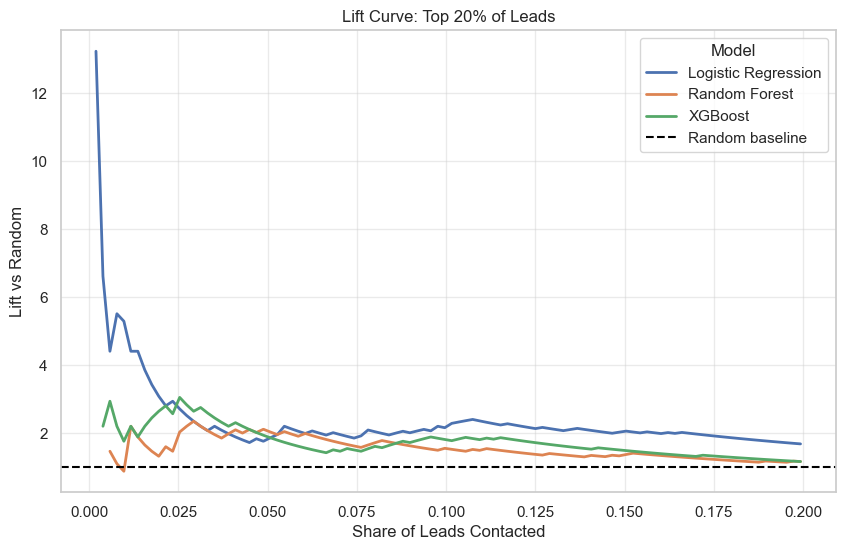

In [48]:
top_20_lift_df = (
    lift_df[
        (lift_df["share_of_leads_contacted"] <= 0.20) &
        (lift_df["lift_at_k"] > 0)
    ]
    .query("rank == 1 or rank % 25 == 0")
    .copy()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=top_20_lift_df,
    x="share_of_leads_contacted",
    y="lift_at_k",
    hue="model",
    linewidth=2
)

plt.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline"
)

plt.title("Lift Curve: Top 20% of Leads")
plt.xlabel("Share of Leads Contacted")
plt.ylabel("Lift vs Random")
plt.legend(title="Model")
plt.grid(True, alpha=0.4)
plt.show()

In [49]:
K_VALUES = [50, 100, 200, 500, 1000]

rows = []
base_rate = results_df[TARGET_COL].mean()
total_conversions = results_df[TARGET_COL].sum()

for model_name, score_col in SCORE_COLS.items():
    ranked = results_df.sort_values(score_col, ascending=False).reset_index(drop=True)

    for k in K_VALUES:
        top_k = ranked.head(k)

        conversions_at_k = top_k[TARGET_COL].sum()
        precision_at_k = conversions_at_k / k
        recall_at_k = conversions_at_k / total_conversions
        lift_at_k = precision_at_k / base_rate

        rows.append({
            "model": model_name,
            "K": k,
            "conversions_at_K": conversions_at_k,
            "precision_at_K": precision_at_k,
            "recall_at_K": recall_at_k,
            "lift_at_K": lift_at_k,
        })

for k in K_VALUES:
    expected_conversions = k * base_rate

    rows.append({
        "model": "Random baseline",
        "K": k,
        "conversions_at_K": expected_conversions,
        "precision_at_K": base_rate,
        "recall_at_K": expected_conversions / total_conversions,
        "lift_at_K": 1.0,
    })

top_k_metrics_df = pd.DataFrame(rows)

display(
    top_k_metrics_df
    .sort_values(["K", "lift_at_K"], ascending=[True, False])
    .round(4)
)

,model,K,conversions_at_K,precision_at_K,recall_at_K,lift_at_K
0,Logistic Regression,50,3.0000,0.0600,0.0259,6.6207
10,XGBoost,50,1.0000,0.0200,0.0086,2.2069
15,Random baseline,50,0.4531,0.0091,0.0039,1.0000
5,Random Forest,50,0.0000,0.0000,0.0000,0.0000
1,Logistic Regression,100,5.0000,0.0500,0.0431,5.5172
11,XGBoost,100,2.0000,0.0200,0.0172,2.2069
6,Random Forest,100,1.0000,0.0100,0.0086,1.1034
16,Random baseline,100,0.9062,0.0091,0.0078,1.0000
2,Logistic Regression,200,7.0000,0.0350,0.0603,3.8621
12,XGBoost,200,4.0000,0.0200,0.0345,2.2069


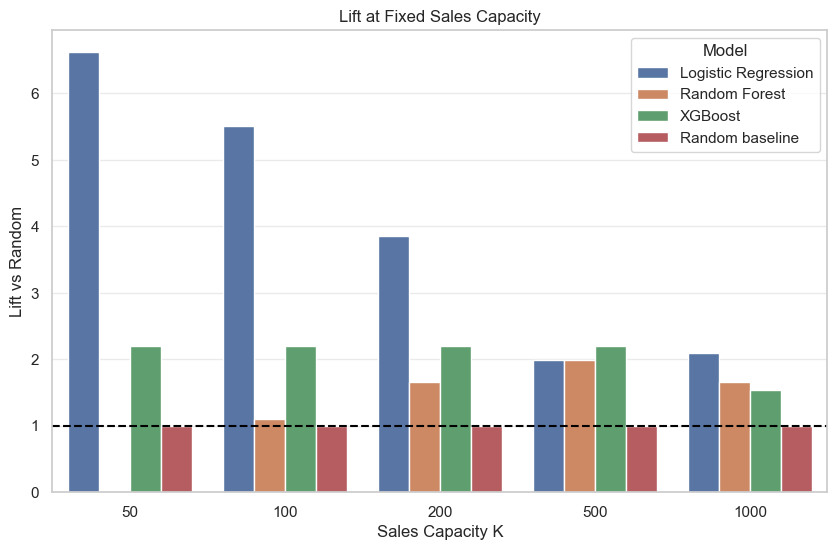

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_k_metrics_df,
    x="K",
    y="lift_at_K",
    hue="model"
)

plt.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

plt.title("Lift at Fixed Sales Capacity")
plt.xlabel("Sales Capacity K")
plt.ylabel("Lift vs Random")
plt.legend(title="Model")
plt.grid(True, axis="y", alpha=0.4)
plt.show()

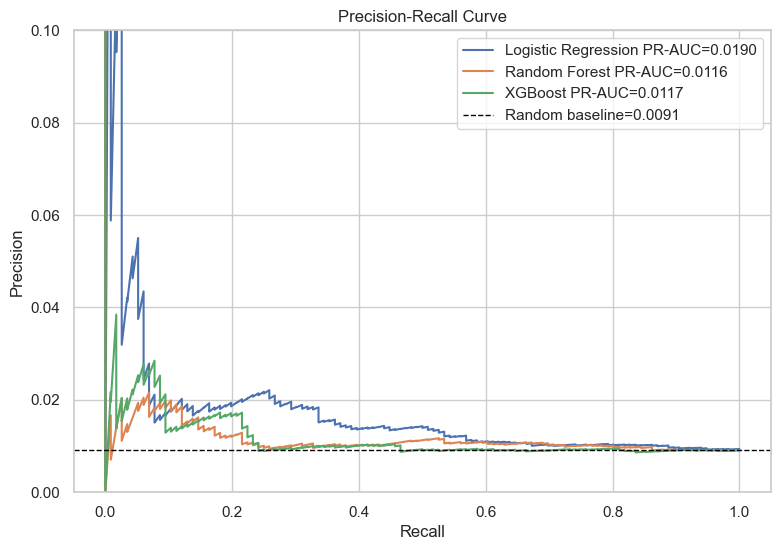

In [29]:
plt.figure(figsize=(9, 6))

base_rate = results_df[TARGET_COL].mean()

for model_name, score_col in SCORE_COLS.items():
    y_true = results_df[TARGET_COL].values
    y_score = results_df[score_col].values

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_score
    )

    pr_auc = average_precision_score(y_true, y_score)

    plt.plot(
        recall,
        precision,
        label=f"{model_name} PR-AUC={pr_auc:.4f}"
    )

plt.axhline(
    base_rate,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Random baseline={base_rate:.4f}"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim(0, max(0.1, base_rate * 10))
plt.legend()
plt.grid(True)
plt.show()

In [30]:
ranking_summary_df[
    ["model", "PR_AUC_average_precision"]
].sort_values(
    "PR_AUC_average_precision",
    ascending=False
)

,model,PR_AUC_average_precision
0,Logistic Regression,0.018993
2,XGBoost,0.011746
1,Random Forest,0.011552


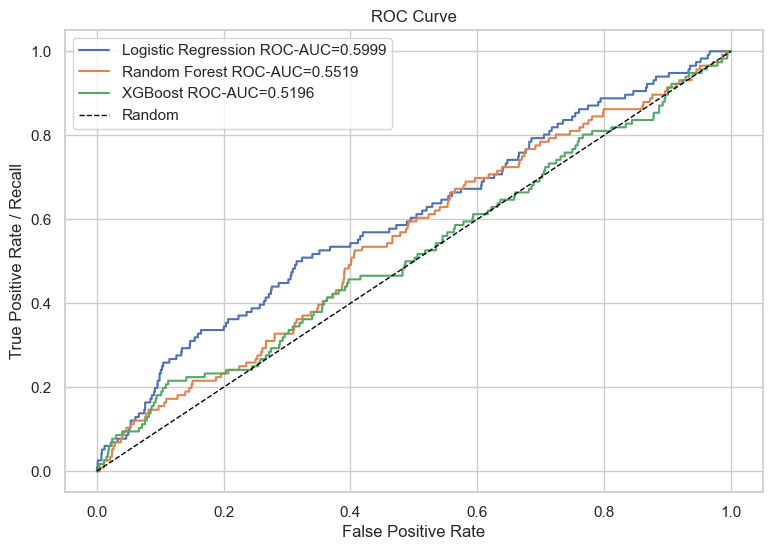

In [31]:
plt.figure(figsize=(9, 6))

for model_name, score_col in SCORE_COLS.items():
    y_true = results_df[TARGET_COL].values
    y_score = results_df[score_col].values

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} ROC-AUC={roc_auc:.4f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    linewidth=1,
    label="Random"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
ranking_summary_df[
    ["model", "ROC_AUC"]
].sort_values(
    "ROC_AUC",
    ascending=False
)

,model,ROC_AUC
0,Logistic Regression,0.599930
1,Random Forest,0.551870
2,XGBoost,0.519556


In [34]:
base_rate = results_df[TARGET_COL].mean()

ranking_summary_df["base_conversion_rate"] = base_rate
ranking_summary_df["PR_AUC_lift_over_random"] = (
    ranking_summary_df["PR_AUC_average_precision"] / base_rate
)

display(
    ranking_summary_df
    .sort_values("PR_AUC_average_precision", ascending=False)
    .round(4)
)

,model,PR_AUC_average_precision,ROC_AUC,base_conversion_rate,PR_AUC_lift_over_random
0,Logistic Regression,0.0190,0.5999,0.0091,2.0958
2,XGBoost,0.0117,0.5196,0.0091,1.2961
1,Random Forest,0.0116,0.5519,0.0091,1.2747
